In [22]:
import numpy as np
import pandas as pd
from scipy.special import gammaln
from pathlib import Path
from scipy.stats import poisson
from scipy.optimize import minimize
from itertools import product
import time
from itertools import combinations
import warnings
import random
from collections import Counter
from scipy.optimize import minimize_scalar
warnings.filterwarnings("ignore")

In [23]:
DIR = Path().resolve()
ROOT = DIR.parent
results = pd.read_csv(Path(ROOT/"data/raw/results.csv"))
goalscorers = pd.read_csv(Path(ROOT/"data/raw/goalscorers.csv"))
shootouts = pd.read_csv(Path(ROOT/"data/raw/shootouts.csv"))
former_names = pd.read_csv(Path(ROOT/"data/raw/former_names.csv"))

In [24]:
results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0000,0.0000,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0000,2.0000,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0000,1.0000,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0000,2.0000,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0000,0.0000,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [25]:
results["date"] = pd.to_datetime(results["date"])

CUTOFF_YEAR = 1966

COMPETITIVE = {
    "FIFA World Cup":3.0,
    "FIFA World Cup qualification":1.5,
    "UEFA Euro":2.5,
    "UEFA Euro qualification":1.0,
    "Copa América":2.5,
    "CONMEBOL World Cup qualification":1.0,
    "CAF World Cup qualification":1.0,
    "AFC World Cup qualification":1.0,
    "CONCACAF World Cup qualification":1.0,
    "OFC World Cup qualification":1.0,
    "UEFA Nations League":2.0,
    "AFC Asian Cup":1.0,
    "Africa Cup of Nations":1.0,
    "CONCACAF Gold Cup":1.0,
}

df = results[(results["date"].dt.year >= CUTOFF_YEAR) & (results["tournament"].isin(COMPETITIVE))].copy().reset_index(drop=True)
print(f"Matches after filter: {len(df)}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique teams: {pd.unique(pd.concat([df['home_team'], df['away_team']])).shape[0]}")
df[["date","home_team","away_team","home_score","away_score","tournament","neutral"]].head()


Matches after filter: 13907
Date range: 1966-07-11 → 2026-06-27
Unique teams: 216


,date,home_team,away_team,home_score,away_score,tournament,neutral
0,1966-07-11,England,Uruguay,0.0000,0.0000,FIFA World Cup,False
1,1966-07-12,Brazil,Bulgaria,2.0000,0.0000,FIFA World Cup,True
2,1966-07-12,Germany,Switzerland,5.0000,0.0000,FIFA World Cup,True
3,1966-07-12,North Korea,Russia,0.0000,3.0000,FIFA World Cup,True
4,1966-07-13,Argentina,Spain,2.0000,1.0000,FIFA World Cup,True


In [26]:
WC_START = pd.Timestamp("2026-06-11")
train = df[df["date"] < WC_START].copy()
home_counts = train["home_team"].value_counts()
away_counts = train["away_team"].value_counts()

matches_played = home_counts.add(away_counts, fill_value=0).astype(int).to_dict()

print(f"Training matches: {len(train)}")
print(f"Last training match: {train['date'].max().date()}")

Training matches: 13835
Last training match: 2026-03-31


In [27]:
all_teams = sorted(pd.unique(pd.concat([train["home_team"], train["away_team"]])))
team_index = {t: i for i, t in enumerate(all_teams)}
n_teams = len(all_teams)
print(f"Teams in model: {n_teams}")
print("England index:", team_index.get("England", "NOT FOUND"))

Teams in model: 216
England index: 61


## Dixon-Coles model implementation

$\tau_{\lambda, \mu}(x,y) = \begin{cases} 1-\lambda\rho & \text{if}\, x = y = 0, \\ 
1+\lambda\rho & \text{if}\, x=0, y=1,\\ 
1+\mu\rho & \text{if}\, x=1, y=0, \\
1-\rho & \text{if}\, x=y=1,\\
1 & \text{otherwise.} \end{cases}$

In [28]:
#Exponentially weight older matches down
#xi=0.001 means a match 365 days ago has weight 0.48 vs today
#Chosen 0.001 after grid search
def time_weight(date, xi=0.001):
    days_ago = (WC_START - pd.Timestamp(date)).days
    return np.exp(-xi * days_ago)

train["weight"] = train["date"].apply(time_weight) * train['tournament'].map(COMPETITIVE).fillna(1.0)

#Tau correction (Dixon-Coles low-score fix) 
# rho is a small negative correlation parameter (~-0.1)
# It adjusts the probability of 0-0, 1-0, 0-1, 1-1 scorelines
def tau(x, y, lam, mu, rho):
    if x == 0 and y == 0:
        return 1 - lam * mu * rho
    elif x == 0 and y == 1:
        return 1 + lam * rho
    elif x == 1 and y == 0:
        return 1 + mu * rho
    elif x == 1 and y == 1:
        return 1 - rho
    else:
        return 1.0

# ── Expected goals ────────────────────────────────────────────────────────────
# lambda (home expected goals) = attack_home * defence_away * [host_bonus]
# mu     (away expected goals) = attack_away * defence_home
# Using log-linear form so parameters are unbounded and exp() keeps goals > 0
#
# params layout:
#   params[0 : n_teams]            = log attack for each team
#   params[n_teams : 2*n_teams]    = log defence for each team  (higher = worse)
#   params[2*n_teams]              = rho  (low-score correction)
#   params[2*n_teams + 1]          = host_bonus (log scale, 0 = no bonus)
#
# Identifiability constraint: fix attack[0] = 0  (i.e. exp(0) = 1)
# This pins the scale so the optimiser doesn't drift

def get_lambda_mu(params, home_idx, away_idx, neutral, host_teams_idx):
    log_attack  = params[:n_teams]
    log_defence = params[n_teams:2*n_teams]
    host_bonus  = params[2*n_teams + 1]

    is_host_home = 1.0 if (not neutral and home_idx in host_teams_idx) else 0.0
    is_host_away = 1.0 if (not neutral and away_idx in host_teams_idx) else 0.0

    lam = np.exp(log_attack[home_idx] - log_defence[away_idx] + is_host_home * host_bonus)
    mu  = np.exp(log_attack[away_idx] - log_defence[home_idx] + is_host_away * host_bonus)
    return lam, mu

print("Core functions defined.")
print(f"Parameter vector length: {2*n_teams + 2}")


Core functions defined.
Parameter vector length: 434


In [29]:
# 2026 World Cup host nations
HOST_TEAMS = {"United States", "Canada", "Mexico"}
host_teams_idx = {team_index[t] for t in HOST_TEAMS if t in team_index}

# ── Pre-compute arrays ONCE outside the likelihood function ──────────────────
home_idx_arr  = train["home_team"].map(team_index).values.astype(int)
away_idx_arr  = train["away_team"].map(team_index).values.astype(int)
home_score    = train["home_score"].values.astype(int)
away_score    = train["away_score"].values.astype(int)
weights_arr   = train["weight"].values
neutral_arr   = train["neutral"].values.astype(bool)

# Host flag arrays (1 if team is a host nation playing at home)
is_host_arr   = np.array([
    1.0 if (not n and hi in host_teams_idx) else 0.0
    for n, hi in zip(neutral_arr, home_idx_arr)
])

# # Precompute log-factorial for scores (max goals assumed <= 15)
# MAX_G = 15
#log_fact = np.zeros(MAX_G + 1)
# for i in range(1, MAX_G + 2):
#     log_fact[i-1] = np.sum(np.log(np.arange(1, i+1))) if i > 0 else 0.0
# log_fact = np.array([0.0] + list(np.cumsum(np.log(np.arange(1, MAX_G + 2)))))

log_fact_x = gammaln(home_score + 1)
log_fact_y = gammaln(away_score + 1)

def neg_log_likelihood(params):
    log_att = params[:n_teams]
    log_def = params[n_teams:2*n_teams]
    rho     = params[2*n_teams]
    h_bonus = params[2*n_teams + 1]

    # Vectorised lambda and mu for all matches at once
    lam = np.exp(log_att[home_idx_arr] - log_def[away_idx_arr] + is_host_arr * h_bonus)
    mu  = np.exp(log_att[away_idx_arr] - log_def[home_idx_arr])

    x = home_score
    y = away_score

    # Poisson log-prob (vectorised)
    log_p = (x * np.log(lam) - lam - log_fact_x
           + y * np.log(mu)  - mu  - log_fact_y)

    # Tau correction (only affects 4 scoreline types)
    log_tau = np.zeros(len(x))
    mask_00 = (x==0) & (y==0)
    mask_01 = (x==0) & (y==1)
    mask_10 = (x==1) & (y==0)
    mask_11 = (x==1) & (y==1)

    # Clip to avoid log(0)
    log_tau[mask_00] = np.log(np.maximum(1 - lam[mask_00]*mu[mask_00]*rho, 1e-10))
    log_tau[mask_01] = np.log(np.maximum(1 + lam[mask_01]*rho,             1e-10))
    log_tau[mask_10] = np.log(np.maximum(1 + mu[mask_10]*rho,              1e-10))
    log_tau[mask_11] = np.log(np.maximum(1 - rho,                          1e-10))

    return -np.sum(weights_arr * (log_p + log_tau))




In [30]:
# VAL_START = pd.Timestamp('2024-12-01')

# df_inner = df[df['date'] < VAL_START].copy()       # inner train
# df_val   = df[(df['date'] >= VAL_START) & 
#               (df['date'] < WC_START)].copy()       # validation


# def fit_model(train_df, xi):
#     weights = train_df['date'].apply(
#         lambda d: np.exp(-xi * (WC_START - d).days)
#     ).values

#     hi = train_df['home_team'].map(team_index).values.astype(int)
#     ai = train_df['away_team'].map(team_index).values.astype(int)
#     hs = train_df['home_score'].values.astype(int)
#     as_ = train_df['away_score'].values.astype(int)
#     neutral = train_df['neutral'].values.astype(bool)
#     ishost  = np.array([
#         1.0 if not n and h in host_teams_idx else 0.0
#         for n, h in zip(neutral, hi)
#     ])

#     logfact = np.array([0.0] + list(np.cumsum(np.log(np.arange(1, 15 + 2)))))
#     lfx = gammaln(hs + 1)
#     lfy = gammaln(as_ + 1)

#     def neg_ll(params):
#         la = params[:n_teams]
#         ld = params[n_teams:2*n_teams]
#         rho = params[2*n_teams]
#         hb  = params[2*n_teams + 1]

#         lam = np.exp(la[hi] - ld[ai] + ishost * hb)
#         mu  = np.exp(la[ai] - ld[hi])

#         logp = hs*np.log(lam) - lam - lfx + as_*np.log(mu) - mu - lfy

#         logtau = np.zeros(len(hs))
#         m00 = (hs==0)&(as_==0); m01 = (hs==0)&(as_==1)
#         m10 = (hs==1)&(as_==0); m11 = (hs==1)&(as_==1)
#         logtau[m00] = np.log(np.maximum(1 - lam[m00]*mu[m00]*rho, 1e-10))
#         logtau[m01] = np.log(np.maximum(1 + lam[m01]*rho,         1e-10))
#         logtau[m10] = np.log(np.maximum(1 + mu[m10]*rho,          1e-10))
#         logtau[m11] = np.log(np.maximum(1 - rho,                  1e-10))

#         return -np.sum(weights * (logp + logtau))

#     x0 = np.concatenate([np.zeros(n_teams), np.zeros(n_teams), [-0.1, 0.1]])
#     res = minimize(neg_ll, x0, method='SLSQP',
#                    constraints={'type': 'eq', 'fun': lambda p: p[0]},
#                    options={'maxiter': 500, 'disp': False})
#     return res.x if res.success else None


# # ── Validation scorer ───────────────────────────────────────────────────────
# def val_log_likelihood(params, val_df):
#     """Log-likelihood of params on val_df (no weighting — equal weight)."""
#     la  = params[:n_teams]
#     ld  = params[n_teams:2*n_teams]
#     rho = params[2*n_teams]
#     hb  = params[2*n_teams + 1]

#     hi  = val_df['home_team'].map(team_index).values.astype(int)
#     ai  = val_df['away_team'].map(team_index).values.astype(int)
#     hs  = val_df['home_score'].values.astype(int)
#     as_ = val_df['away_score'].values.astype(int)
#     neutral = val_df['neutral'].values.astype(bool)
#     ishost  = np.array([
#         1.0 if not n and h in host_teams_idx else 0.0
#         for n, h in zip(neutral, hi)
#     ])

#     lfx = gammaln(hs + 1)
#     lfy = gammaln(as_ + 1)

#     lam = np.exp(la[hi] - ld[ai] + ishost * hb)
#     mu  = np.exp(la[ai] - ld[hi])

#     logp = hs*np.log(lam) - lam - lfx + as_*np.log(mu) - mu - lfy

#     logtau = np.zeros(len(hs))
#     m00 = (hs==0)&(as_==0); m01 = (hs==0)&(as_==1)
#     m10 = (hs==1)&(as_==0); m11 = (hs==1)&(as_==1)
#     logtau[m00] = np.log(np.maximum(1 - lam[m00]*mu[m00]*rho, 1e-10))
#     logtau[m01] = np.log(np.maximum(1 + lam[m01]*rho,         1e-10))
#     logtau[m10] = np.log(np.maximum(1 + mu[m10]*rho,          1e-10))
#     logtau[m11] = np.log(np.maximum(1 - rho,                  1e-10))

#     return np.sum(logp + logtau)


# # ── Grid search over xi ─────────────────────────────────────────────────────
# xi_candidates = [0.0005, 0.001, 0.0015, 0.002, 0.003, 0.004, 0.005, 0.007, 0.01]
# results = []

# for xi in xi_candidates:
#     print(f"Fitting xi={xi}...", end=' ')
#     params = fit_model(df_inner, xi)
#     if params is None:
#         print("FAILED")
#         continue
#     vll = val_log_likelihood(params, df_val)
#     results.append((xi, vll))
#     print(f"val LL = {vll:.2f}")

# results_df = pd.DataFrame(results, columns=['xi', 'val_log_likelihood'])
# print("\n", results_df.sort_values('val_log_likelihood', ascending=False))

# best_xi = results_df.loc[results_df['val_log_likelihood'].idxmax(), 'xi']
# print(f"\nBest xi: {best_xi}")

In [31]:
#Initialise params
# log_attack = 0 for all teams (exp(0)=1, neutral starting point)
# log_defence= 0 for all teams
# rho = -0.1  (small negative correlation)
# host_bonus = 0.1 (slight log-scale boost for hosts)
init_params = np.concatenate([
    np.zeros(n_teams),   # log attack
    np.zeros(n_teams),   # log defence
    [-0.1],              # rho
    [0.1],               # host_bonus
])

#Identifiability constraint, fix first team's attack to 0
constraints = [{"type": "eq", "fun": lambda p: p[0]}]

print("Fitting Dixon-Coles model... (this may take a minute or so)")
result = minimize(
    neg_log_likelihood,
    init_params,
    method="SLSQP",
    constraints=constraints,
    options={"maxiter": 500, "disp": True},
)

fitted_params = result.x
print(f"\nOptimisation success: {result.success}")
print(f"Final log-likelihood: {-result.fun:.2f}")


Fitting Dixon-Coles model... (this may take a minute or so)
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4783.894784621901
            Iterations: 151
            Function evaluations: 65904
            Gradient evaluations: 151

Optimisation success: True
Final log-likelihood: -4783.89


In [32]:
log_attack  = fitted_params[:n_teams]
log_defence = fitted_params[n_teams:2*n_teams]
rho_fit     = fitted_params[2*n_teams]
host_bonus  = fitted_params[2*n_teams + 1]

# #Net strength = attack - defence
# strengths = pd.DataFrame({
#     "team":    all_teams,
#     "attack":  np.exp(log_attack),
#     "defence": np.exp(log_defence),   # lower = better defence
#     "net":     log_attack - log_defence,
# }).sort_values("net", ascending=False).reset_index(drop=True)

# print(f"rho  = {rho_fit:.4f}  (low-score correction)")
# print(f"host_bonus = {host_bonus:.4f}  (log-scale boost for USA/Canada/Mexico)")
# print()
# print("=== Top 20 teams by net strength ===")
# print(strengths.head(20).to_string(index=False))
# print()
# print("=== England ===")
# print(strengths[strengths["team"] == "England"])

#Build raw strengths table
strengths = pd.DataFrame({
    "team":    all_teams,
    "log_attack":  log_attack,
    "log_defence": log_defence,
})

#Add matches played (0 if team never appears in train)
strengths["matches_played"] = strengths["team"].map(matches_played).fillna(0).astype(int)



#Empirical Bayes shrinkage towards global mean
k = 60  # tune: higher = more shrinkage, lower = less

attack_prior  = strengths["log_attack"].mean()
defence_prior = strengths["log_defence"].mean()

mp = strengths["matches_played"]

strengths["log_attack_shrunk"] = (
    strengths["log_attack"] * mp + attack_prior * k
) / (mp + k)

strengths["log_defence_shrunk"] = (
    strengths["log_defence"] * mp + defence_prior * k
) / (mp + k)

# Derived scales
strengths["attack"]        = np.exp(strengths["log_attack"])
strengths["defence"]       = np.exp(strengths["log_defence"])
strengths["attack_shrunk"] = np.exp(strengths["log_attack_shrunk"])
strengths["defence_shrunk"]= np.exp(strengths["log_defence_shrunk"])

# Net strengths: raw vs shrunk
strengths["net_raw"]    = strengths["log_attack"] - strengths["log_defence"]
strengths["net_shrunk"] = strengths["log_attack_shrunk"] - strengths["log_defence_shrunk"]

# For printing, sort by shrunk net
strengths = strengths.sort_values("net_shrunk", ascending=False).reset_index(drop=True)

print(f"rho  = {rho_fit:.4f}  (low-score correction)")
print(f"host_bonus = {host_bonus:.4f}  (log-scale boost for USA/Canada/Mexico)")
print()
print("=== Top 20 teams by shrinkage-adjusted net strength ===")
print(strengths.head(20)[["team", "attack_shrunk", "defence_shrunk", "net_shrunk"]]
      .to_string(index=False))
print()
print("=== England ===")
print(strengths[strengths["team"] == "England"]
      [["team", "matches_played", "attack_shrunk", "defence_shrunk", "net_shrunk"]])
#overwrite net column
strengths["net"] = strengths["net_shrunk"]


rho  = -0.0493  (low-score correction)
host_bonus = 0.4713  (log-scale boost for USA/Canada/Mexico)

=== Top 20 teams by shrinkage-adjusted net strength ===
                            team  attack_shrunk  defence_shrunk  net_shrunk
Saint Vincent and the Grenadines         1.9354          0.9998      0.6605
                          Israel         4.5989          2.5010      0.6091
                         Iceland         4.4533          2.4437      0.6001
                         Bermuda         1.9566          1.1033      0.5729
                          Norway         6.6985          3.9491      0.5284
                         Bolivia         3.7467          2.2194      0.5236
                           Qatar         3.5142          2.1677      0.4832
                         Germany         7.6428          4.7507      0.4755
                          Sweden         5.3732          3.3885      0.4610
                          Gambia         2.3947          1.5298      0.4482
       

In [33]:
def match_score_matrix(team_a, team_b, neutral=True, max_goals=8):
    ai = team_index[team_a]
    bi = team_index[team_b]
    lam, mu = get_lambda_mu(fitted_params, ai, bi, neutral, host_teams_idx)

    matrix = np.zeros((max_goals+1, max_goals+1))
    for x in range(max_goals+1):
        for y in range(max_goals+1):
            t = tau(x, y, lam, mu, rho_fit)
            matrix[x, y] = (t
                            * poisson.pmf(x, lam)
                            * poisson.pmf(y, mu))
    return matrix, lam, mu

def match_probs(team_a, team_b, neutral=True):
    m, lam, mu = match_score_matrix(team_a, team_b, neutral)
    win  = np.tril(m, -1).sum()   # team_a scores more
    draw = np.trace(m)
    loss = np.triu(m, 1).sum()    # team_b scores more
    return {"win": win, "draw": draw, "loss": loss, "lambda": lam, "mu": mu}

#Testing England vs a few teams
test_matchups = [
    ("England", "Tunisia"),
    ("England", "France"),
    ("England", "Spain"),
    ("England", "Argentina"),
    ("England", "Brazil"),
]

print(f"{'Matchup':<35} {'P(Eng win)':>10} {'P(Draw)':>8} {'P(Eng loss)':>12} {'xG Eng':>7} {'xG Opp':>7}")
print("-" * 82)
for home, away in test_matchups:
    try:
        p = match_probs(home, away, neutral=True)
        print(f"England vs {away:<24} {p['win']:>10.1%} {p['draw']:>8.1%} {p['loss']:>12.1%} {p['lambda']:>7.2f} {p['mu']:>7.2f}")
    except KeyError as e:
        print(f"  Team not found: {e}")


Matchup                             P(Eng win)  P(Draw)  P(Eng loss)  xG Eng  xG Opp
----------------------------------------------------------------------------------
England vs Tunisia                       33.0%    46.8%        20.2%    0.60    0.41
England vs France                        40.1%    30.6%        29.4%    1.18    0.97
England vs Spain                         31.2%    28.6%        40.2%    1.12    1.31
England vs Argentina                     35.0%    32.9%        32.1%    0.99    0.93
England vs Brazil                        39.9%    32.5%        27.6%    1.08    0.85


In [34]:
WC_GROUPS = {
    "A": ["Mexico", "South Africa", "Czech Republic", "South Korea"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Curaçao", "Ivory Coast", "Ecuador"], 
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"]
    
}

print("Groups:")
for g, teams in WC_GROUPS.items():
    print(f"  Group {g}: {', '.join(teams)}")

Groups:
  Group A: Mexico, South Africa, Czech Republic, South Korea
  Group B: Canada, Bosnia and Herzegovina, Qatar, Switzerland
  Group C: Brazil, Morocco, Haiti, Scotland
  Group D: United States, Paraguay, Australia, Turkey
  Group E: Germany, Curaçao, Ivory Coast, Ecuador
  Group F: Netherlands, Japan, Sweden, Tunisia
  Group G: Belgium, Egypt, Iran, New Zealand
  Group H: Spain, Cape Verde, Saudi Arabia, Uruguay
  Group I: France, Senegal, Iraq, Norway
  Group J: Argentina, Algeria, Austria, Jordan
  Group K: Portugal, DR Congo, Uzbekistan, Colombia
  Group L: England, Croatia, Ghana, Panama


In [35]:
missing = [t for g in WC_GROUPS.values() for t in g if t not in team_index]
print("WC teams NOT in model:", missing)

print("Curaçao" in team_index)   # might be "Curacao" without accent
print("Côte d'Ivoire" in team_index)  # might be "Ivory Coast"

WC teams NOT in model: []
True
False


### Round of 32 Bracket
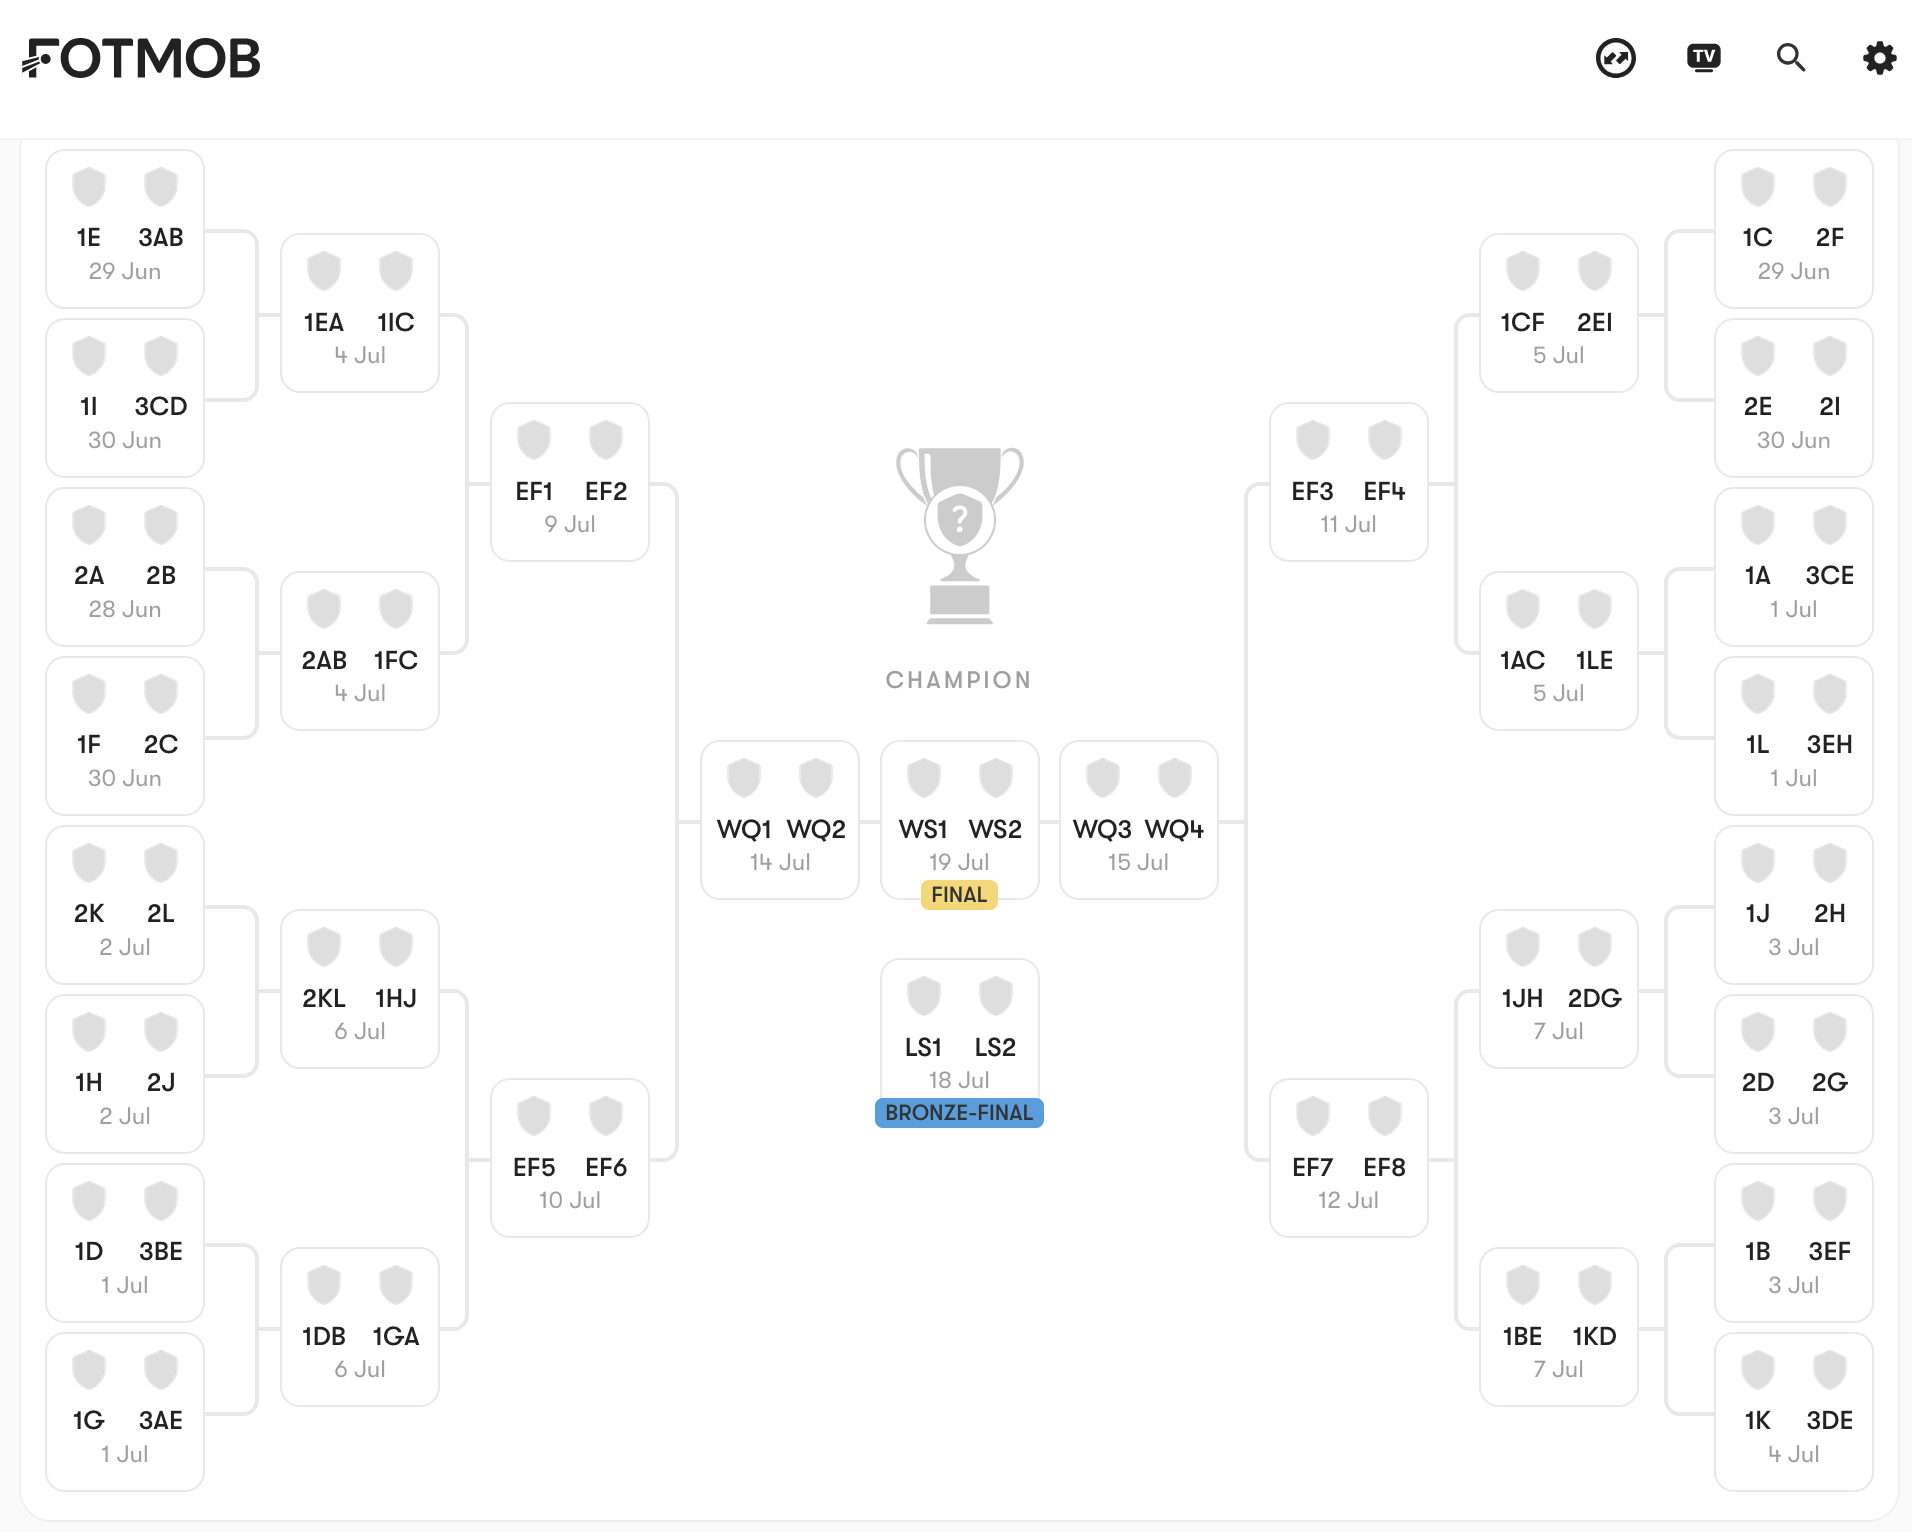

In [36]:
R32_FIXED = [
    ("1E", "3ABCDF"),
    ("1I", "3CDFGH"),
    ("2A", "2B"),
    ("1F", "2C"),
    ("2K", "2L"),
    ("1H", "2J"),
    ("1D", "3BEFIJ"),
    ("1G", "3AEHIJ"),
    ("1C", "2F"),
    ("2E", "2I"),
    ("1A", "3CEFHI"),
    ("1L", "3EHIJK"),
    ("1J", "2H"),
    ("2D", "2G"),
    ("1B", "3EFGIJ"),
    ("1K", "3DEIJL"),
]

In [37]:
print("Pre-caching score matrices...")
score_cache = {}
wc_teams = [t for g in WC_GROUPS.values() for t in g if t in team_index]

for team_a, team_b in combinations(wc_teams, 2):
    m, lam, mu = match_score_matrix(team_a, team_b, neutral=True)
    # Use the cache instead
    score_cache[(team_a, team_b)] = (m, lam, mu)
    score_cache[(team_b, team_a)] = (m.T, mu, lam)

print(f"Cached {len(score_cache)} matchups")

Pre-caching score matrices...
Cached 2256 matchups


In [38]:
def simulate_group(teams):
    table = {t: {"pts": 0, "gd": 0, "gf": 0} for t in teams}

    for i, home in enumerate(teams):
        for away in teams[i+1:]:
            #m, lam, mu = match_score_matrix(home, away, neutral=True)
            # Use the cache instead
            m, lam, mu = score_cache[(home, away)]
            # Sample a scoreline from the probability matrix
            flat_probs = m.flatten()
            flat_probs = np.maximum(flat_probs, 0)
            flat_probs /= flat_probs.sum()
            idx = np.random.choice(len(flat_probs), p=flat_probs)
            x, y = divmod(idx, m.shape[1])

            # Update table
            table[home]["gf"] += x
            table[home]["gd"] += x - y
            table[away]["gf"] += y
            table[away]["gd"] += y - x

            if x > y:
                table[home]["pts"] += 3
            elif x == y:
                table[home]["pts"] += 1
                table[away]["pts"] += 1
            else:
                table[away]["pts"] += 3

    # Sort: points desc, goal diff desc, goals for desc, then random for remaining
    standings = sorted(
        teams,
        key=lambda t: (table[t]["pts"], table[t]["gd"], table[t]["gf"], random.random()),
        reverse=True,
    )
    return standings, table

# ── Simulate a knockout match ─────────────────────────────────────────────────
def simulate_knockout_match(team_a, team_b):
    m, lam, mu = score_cache[(team_a, team_b)]
    win  = np.tril(m, -1).sum()
    draw = np.trace(m)
    r = random.random()
    if r < win:
        return team_a
    elif r < win + draw:
        #Draw goes to simplified shootout (slightly favour stronger team)
        net_a = strengths.loc[strengths["team"]==team_a, "net"].values[0]
        net_b = strengths.loc[strengths["team"]==team_b, "net"].values[0]
        p_a_wins_pen = 1 / (1 + np.exp(-(net_a - net_b)))  # logistic
        return team_a if random.random() < p_a_wins_pen else team_b
    else:
        return team_b

In [39]:
def simulate_tournament():
    results_sim = {t: 0 for g in WC_GROUPS.values() for t in g}

    #1. Simulate all group stages
    group_standings = {}
    all_third_place = []
    qualified_third = []
    group = {}

    for grp, teams in WC_GROUPS.items():
        #Skip teams not in model
        valid_teams = [t for t in teams if t in team_index]
        if len(valid_teams) < len(teams):
            missing = [t for t in teams if t not in team_index]
            print(f"  Warning: {missing} not in model, using available teams")

        standings, table = simulate_group(valid_teams)
        group_standings[grp] = standings

        #Record round of 32 qualification
        for t in standings[:2]:
            results_sim[t] = max(results_sim[t], 32)

        #Third place recorded separately
        if len(standings) > 2:
            third_place = standings[2]
            all_third_place.append((third_place, table[third_place]))
            group[third_place] = grp

    #2. Pick best 8 third-place teams
    all_third_place.sort(
        key=lambda x: (x[1]["pts"], x[1]["gd"], x[1]["gf"]),
        reverse=True
    )
    qualified_third = [t for t, _ in all_third_place[:8]]
    for t in qualified_third:
        results_sim[t] = max(results_sim[t], 32)

    #3. Build R32 bracket (simplification: pair group winners vs qualified 3rds/2nds)
    r32_teams = []

    for grp in sorted(WC_GROUPS.keys()):
        r32_teams.append(group_standings[grp][0])  # winner
        r32_teams.append(group_standings[grp][1])  # runner-up

    r32_teams += qualified_third

    assert len(r32_teams) == 32, f"Expected 32 teams, got {len(r32_teams)}"
    assert len(set(r32_teams)) == 32, "Duplicate teams found in R32"

    #random.shuffle(r32_teams)
    r32_matches = list(zip(r32_teams[::2], r32_teams[1::2]))

    # 4. Simulate knockout rounds
    current_round = r32_matches
    round_code = 32

    while len(current_round) > 1:
        next_round = []
        for team_a, team_b in current_round:
            winner = simulate_knockout_match(team_a, team_b)
            loser = team_b if winner == team_a else team_a
            next_round.append(winner)

            #results_sim[winner] = max(results_sim.get(winner, 0), round_code)
            #results_sim[loser]  = max(results_sim.get(loser,  0), round_code)
            results_sim[winner] = round_code
            results_sim[loser]  = round_code
            
        round_code //= 2
        current_round = list(zip(next_round[::2], next_round[1::2]))

    # Final (2 teams left, round_code should now be 2)
    team_a, team_b = current_round[0]
    winner = simulate_knockout_match(team_a, team_b)
    loser = team_b if winner == team_a else team_a

    #results_sim[loser]  = max(results_sim.get(loser,  0), 2)
    # results_sim[winner] = 1
    results_sim[loser] = 2
    results_sim[winner] = 1
    
    
    print("End-of-sim round codes:", Counter(results_sim.values()))
    return results_sim

#Test one sim
print("Running one test simulation...")
test_result = simulate_tournament()
print(f"England result (round code): {test_result.get('England', 'N/A')}")

print(Counter(test_result.values()))


Running one test simulation...
End-of-sim round codes: Counter({0: 16, 32: 16, 16: 8, 8: 4, 4: 2, 2: 1, 1: 1})
England result (round code): 1
Counter({0: 16, 32: 16, 16: 8, 8: 4, 4: 2, 2: 1, 1: 1})


In [40]:
start = time.time()
test_result = simulate_tournament()
print(f"One simulation: {time.time() - start:.4f}s")

N_SIMS = 10_000
all_teams_wc = [t for g in WC_GROUPS.values() for t in g]
win_counts  = {t: 0 for t in all_teams_wc}
round_counts = {t: {"R32": 0, "R16": 0, "QF": 0, "SF": 0, "Final": 0, "Win": 0}
                for t in all_teams_wc}
england_opponents = {"R32": {}, "R16": {}, "QF": {}, "SF": {}, "Final": {}}


print(f"Running {N_SIMS:,} simulations...")
for sim in range(N_SIMS):
    res = simulate_tournament()
    for team, rnd in res.items():
        if team not in round_counts:
            continue
        if rnd <= 1:
            round_counts[team]["Win"]   += 1
        if rnd <= 2:
            round_counts[team]["Final"] += 1
        if rnd <= 4:
            round_counts[team]["SF"]    += 1
        if rnd <= 8:
            round_counts[team]["QF"]    += 1
        if rnd <= 16:
            round_counts[team]["R16"]   += 1
        if rnd <= 32:
            round_counts[team]["R32"]   += 1

print("Done!")

probs_df = pd.DataFrame([
    {
        "team":    t,
        "P(R32)":  round_counts[t]["R32"]   / N_SIMS,
        "P(R16)":  round_counts[t]["R16"]   / N_SIMS,
        "P(QF)":   round_counts[t]["QF"]    / N_SIMS,
        "P(SF)":   round_counts[t]["SF"]    / N_SIMS,
        "P(Final)":round_counts[t]["Final"] / N_SIMS,
        "P(Win)":  round_counts[t]["Win"]   / N_SIMS,
    }
    for t in all_teams_wc
]).sort_values("P(Win)", ascending=False).reset_index(drop=True)

print("\n=== World Cup Win Probabilities (Top 20) ===")
pd.options.display.float_format = "{:.1%}".format
print(probs_df.head(20).to_string(index=False))

print("\n=== England specifically ===")
print(probs_df[probs_df["team"] == "England"].to_string(index=False))


End-of-sim round codes: Counter({0: 16, 32: 16, 16: 8, 8: 4, 4: 2, 1: 1, 2: 1})
One simulation: 0.0057s
Running 10,000 simulations...
End-of-sim round codes: Counter({0: 16, 32: 16, 16: 8, 8: 4, 4: 2, 1: 1, 2: 1})
End-of-sim round codes: Counter({0: 16, 32: 16, 16: 8, 8: 4, 4: 2, 1: 1, 2: 1})
End-of-sim round codes: Counter({0: 16, 32: 16, 16: 8, 8: 4, 4: 2, 2: 1, 1: 1})
End-of-sim round codes: Counter({32: 16, 0: 16, 16: 8, 8: 4, 4: 2, 2: 1, 1: 1})
End-of-sim round codes: Counter({32: 16, 0: 16, 16: 8, 8: 4, 4: 2, 1: 1, 2: 1})
End-of-sim round codes: Counter({0: 16, 32: 16, 16: 8, 8: 4, 4: 2, 1: 1, 2: 1})
End-of-sim round codes: Counter({0: 16, 32: 16, 16: 8, 8: 4, 4: 2, 2: 1, 1: 1})
End-of-sim round codes: Counter({32: 16, 0: 16, 16: 8, 8: 4, 4: 2, 2: 1, 1: 1})
End-of-sim round codes: Counter({32: 16, 0: 16, 16: 8, 8: 4, 4: 2, 1: 1, 2: 1})
End-of-sim round codes: Counter({0: 16, 32: 16, 16: 8, 8: 4, 4: 2, 2: 1, 1: 1})
End-of-sim round codes: Counter({32: 16, 0: 16, 16: 8, 8: 4, 4: 2,

In [41]:
#England pre-match probability breakdown
england_group = [t for g, teams in WC_GROUPS.items()
                 for t in teams if "England" in teams and t != "England"]

print("England's Group H opponents:")
for opp in england_group:
    p = match_probs("England", opp, neutral=True)
    print(f"  vs {opp:<25}  Win {p['win']:.1%}  Draw {p['draw']:.1%}  Loss {p['loss']:.1%}"
          f"  (xG: {p['lambda']:.2f} - {p['mu']:.2f})")


England's Group H opponents:
  vs Croatia                    Win 53.0%  Draw 27.2%  Loss 19.8%  (xG: 1.51 - 0.82)
  vs Ghana                      Win 73.6%  Draw 18.6%  Loss 7.8%  (xG: 2.10 - 0.53)
  vs Panama                     Win 90.5%  Draw 7.0%  Loss 1.8%  (xG: 3.35 - 0.39)


In [42]:
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

pd.options.display.float_format = "{:.4f}".format
probs_df.to_csv(OUT / "tournament_probabilities.csv", index=False)
strengths.to_csv(OUT / "team_strengths.csv", index=False)
print(f"Saved to {OUT}")


Saved to /Users/adam/Library/Mobile Documents/com~apple~CloudDocs/Adam/PROJECTS/world-cup-2026-predictor/outputs
